# Interactive Business Dashboard — Global Superstore

**Objective:** Build an interactive Streamlit dashboard to analyze sales, profit, and customer performance.

## Problem Statement
Business teams need visual tools to explore data without writing code. We will build an interactive dashboard using Streamlit that shows KPIs, charts, and filters for the Global Superstore dataset. We run it on Google Colab using ngrok to get a public URL.


## 1: Install Required Libraries

In [1]:
# Install streamlit and pyngrok
# pyngrok creates a public URL so we can view the Streamlit app from Colab
!pip install streamlit -q
!pip install openpyxl -q
!pip install pyngrok -q
!pip install kagglehub -q
print("Done.")


Done.


## Step 2: Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import shutil

%matplotlib inline
print("Libraries imported.")


Libraries imported.


## 3: Download the Dataset

In [3]:
import kagglehub

# Download Global Superstore dataset from Kaggle
path = kagglehub.dataset_download("apoorvaappz/global-super-store-dataset")
print("Downloaded to:", path)

# Copy all files to current folder
for f in os.listdir(path):
    shutil.copy(os.path.join(path, f), f)
    print("Copied:", f)


Using Colab cache for faster access to the 'global-super-store-dataset' dataset.
Downloaded to: /kaggle/input/global-super-store-dataset
Copied: Global_Superstore2.xlsx
Copied: Global_Superstore2.csv


## 4: Verify Dataset

In [4]:
import glob

# Find the file
matches = glob.glob('/content/*uperstore*') + glob.glob('/content/*lobal*tore*')
if matches:
    filename = matches[0]
else:
    all_files = glob.glob('/content/*.csv') + glob.glob('/content/*.xlsx')
    filename = all_files[0]

print("Using file:", filename)

# Load it
if filename.endswith('.xlsx'):
    df = pd.read_excel(filename, engine='openpyxl')
else:
    df = pd.read_csv(filename, encoding='latin-1')

print("Shape:", df.shape)
df.head()

Using file: /content/Global_Superstore2.xlsx
Shape: (51290, 24)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,31-07-2012,31-07-2012,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical
1,26341,IN-2013-77878,05-02-2013,07-02-2013,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical
2,25330,IN-2013-71249,17-10-2013,18-10-2013,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium
3,13524,ES-2013-1579342,28-01-2013,30-01-2013,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium
4,47221,SG-2013-4320,05-11-2013,06-11-2013,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical


## 4: Write the Streamlit App to a File

In [5]:
# %%writefile writes the code in this cell directly to a .py file
# This is how we create the Streamlit app file inside Colab
%%writefile task5_dashboard.py

import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

st.set_page_config(
    page_title="Global Superstore Dashboard",
    layout="wide"
)

@st.cache_data
def load_data():
    import glob
    matches = glob.glob('/content/*uperstore*') + glob.glob('/content/*lobal*tore*')
    if matches:
        filename = matches[0]
    else:
        csvs = glob.glob('/content/*.csv') + glob.glob('/content/*.xlsx')
        filename = csvs[0]

    if filename.endswith('.xlsx'):
        df = pd.read_excel(filename, engine='openpyxl')
    else:
        df = pd.read_csv(filename, encoding='latin-1')

    df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True, errors='coerce')
    df['Year'] = df['Order Date'].dt.year
    return df

df = load_data()

# Sidebar Filters
st.sidebar.title("Filters")

all_regions = sorted(df['Region'].dropna().unique().tolist())
selected_regions = st.sidebar.multiselect("Region", all_regions, default=all_regions)

all_categories = sorted(df['Category'].dropna().unique().tolist())
selected_categories = st.sidebar.multiselect("Category", all_categories, default=all_categories)

filtered_sub = df[df['Category'].isin(selected_categories)]['Sub-Category'].dropna().unique().tolist()
selected_subcategories = st.sidebar.multiselect("Sub-Category", sorted(filtered_sub), default=sorted(filtered_sub))

all_years = sorted(df['Year'].dropna().unique().tolist())
selected_years = st.sidebar.multiselect("Year", all_years, default=all_years)

filtered_df = df[
    (df['Region'].isin(selected_regions)) &
    (df['Category'].isin(selected_categories)) &
    (df['Sub-Category'].isin(selected_subcategories)) &
    (df['Year'].isin(selected_years))
]

st.title("Global Superstore: Business Intelligence Dashboard")
st.markdown("Use the filters on the left to explore sales and profit data.")

if filtered_df.empty:
    st.warning("No data matches the selected filters.")
    st.stop()

# KPI Cards
st.subheader("Key Performance Indicators")
total_sales   = filtered_df['Sales'].sum()
total_profit  = filtered_df['Profit'].sum()
total_orders  = filtered_df['Order ID'].nunique()
profit_margin = (total_profit / total_sales * 100) if total_sales > 0 else 0

col1, col2, col3, col4 = st.columns(4)
col1.metric("Total Sales",   f"${total_sales:,.0f}")
col2.metric("Total Profit",  f"${total_profit:,.0f}")
col3.metric("Total Orders",  f"{total_orders:,}")
col4.metric("Profit Margin", f"{profit_margin:.1f}%")

st.divider()

# Sales by Region and Category
col_a, col_b = st.columns(2)

with col_a:
    st.subheader("Sales by Region")
    region_sales = filtered_df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(6,4))
    sns.barplot(x=region_sales.values, y=region_sales.index, palette='Blues_r', ax=ax)
    ax.set_xlabel("Total Sales ($)")
    ax.set_ylabel("")
    ax.set_title("Sales by Region")
    st.pyplot(fig)
    plt.close()

with col_b:
    st.subheader("Sales by Category")
    cat_sales = filtered_df.groupby('Category')['Sales'].sum()
    fig, ax = plt.subplots(figsize=(5,4))
    ax.pie(cat_sales.values, labels=cat_sales.index, autopct='%1.1f%%',
           colors=sns.color_palette('Set2', len(cat_sales)))
    ax.set_title("Sales Split by Category")
    st.pyplot(fig)
    plt.close()

st.divider()

# Monthly Trend and Profit by Sub-Category
col_c, col_d = st.columns(2)

with col_c:
    st.subheader("Monthly Sales Trend")
    monthly = filtered_df.groupby(filtered_df['Order Date'].dt.to_period('M'))['Sales'].sum()
    monthly.index = monthly.index.astype(str)
    fig, ax = plt.subplots(figsize=(8,4))
    ax.plot(monthly.index, monthly.values, color='steelblue', linewidth=2)
    ax.fill_between(monthly.index, monthly.values, alpha=0.2, color='steelblue')
    tick_positions = range(0, len(monthly), max(1, len(monthly)//10))
    ax.set_xticks([list(monthly.index)[i] for i in tick_positions])
    ax.set_xticklabels([list(monthly.index)[i] for i in tick_positions], rotation=45, ha='right')
    ax.set_title("Monthly Sales Over Time")
    ax.set_xlabel("Month")
    ax.set_ylabel("Sales ($)")
    st.pyplot(fig)
    plt.close()

with col_d:
    st.subheader("Profit by Sub-Category")
    sub_profit = filtered_df.groupby('Sub-Category')['Profit'].sum().sort_values()
    colors = ['#d73027' if v < 0 else '#1a9850' for v in sub_profit.values]
    fig, ax = plt.subplots(figsize=(6,6))
    ax.barh(sub_profit.index, sub_profit.values, color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title("Profit by Sub-Category (Red = Loss)")
    ax.set_xlabel("Profit ($)")
    st.pyplot(fig)
    plt.close()

st.divider()

# Top 5 Customers
st.subheader("Top 5 Customers by Sales")
top_customers = (
    filtered_df.groupby('Customer Name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .reset_index()
)
top_customers['Sales'] = top_customers['Sales'].round(2)
top_customers.columns = ['Customer Name', 'Total Sales ($)']

col_e, col_f = st.columns([1,2])
with col_e:
    st.dataframe(top_customers, use_container_width=True)
with col_f:
    fig, ax = plt.subplots(figsize=(7,4))
    sns.barplot(data=top_customers, x='Total Sales ($)', y='Customer Name',
                palette='viridis', ax=ax)
    ax.set_title("Top 5 Customers by Sales")
    ax.set_xlabel("Total Sales ($)")
    ax.set_ylabel("")
    st.pyplot(fig)
    plt.close()

st.divider()

with st.expander("View Raw Data (first 100 rows)"):
    st.dataframe(filtered_df.head(100))

st.caption("Dashboard built for DevelopersHub Corporation Data Science Internship")


Overwriting task5_dashboard.py


## 5: Set Your ngrok Auth Token


In [6]:
# Paste your ngrok token here
# Get it free from: https://dashboard.ngrok.com/get-started/your-authtoken
from google.colab import userdata
from pyngrok import ngrok, conf

# Read token from Colab secrets
NGROK_TOKEN = userdata.get('NGROK_TOKEN')
conf.get_default().auth_token = NGROK_TOKEN
print("Token set.")


Token set.


## 6: Launch the Dashboard

In [7]:
import subprocess
import time

# Kill any existing streamlit processes
subprocess.run(["pkill", "-f", "streamlit"], capture_output=True)
time.sleep(2)

# Start Streamlit in the background on port 8501
process = subprocess.Popen(
    ["streamlit", "run", "task5_dashboard.py",
     "--server.port", "8501",
     "--server.headless", "true"],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

# Wait for it to start
time.sleep(5)

# Create public URL using ngrok
public_url = ngrok.connect(8501)
print("=" * 50)
print("Dashboard is live at:")
print(public_url)
print("=" * 50)
print("Click the link above to open the dashboard.")
print("Keep this cell running. Stop it to shut down the dashboard.")


Dashboard is live at:
NgrokTunnel: "https://feed-scored-hatchet.ngrok-free.dev" -> "http://localhost:8501"
Click the link above to open the dashboard.
Keep this cell running. Stop it to shut down the dashboard.


## 7: EDA and Key Insights (for Notebook Submission)

In [8]:
# Run basic analysis here to satisfy the notebook checklist

df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True, errors='coerce')
df['Year'] = df['Order Date'].dt.year

print("Shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])


Shape: (51290, 25)

Missing values:
Postal Code    41296
dtype: int64


In [9]:
# Total Sales and Profit by Region
region_summary = df.groupby('Region')[['Sales','Profit']].sum().sort_values('Sales', ascending=False)
print(region_summary)


                       Sales        Profit
Region                                    
Central         2.822303e+06  311403.98164
South           1.600907e+06  140355.76618
North           1.248166e+06  194597.95252
Oceania         1.100185e+06  120089.11200
Southeast Asia  8.844232e+05   17852.32900
North Asia      8.483098e+05  165578.42100
EMEA            8.061613e+05   43897.97100
Africa          7.837732e+05   88871.63100
Central Asia    7.528266e+05  132480.18700
West            7.254578e+05  108418.44890
East            6.787812e+05   91522.78000
Caribbean       3.242809e+05   34571.32104
Canada          6.692817e+04   17817.39000


/tmp/ipykernel_8340/2888827094.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_sales.index, y=cat_sales.values, palette='Set2')


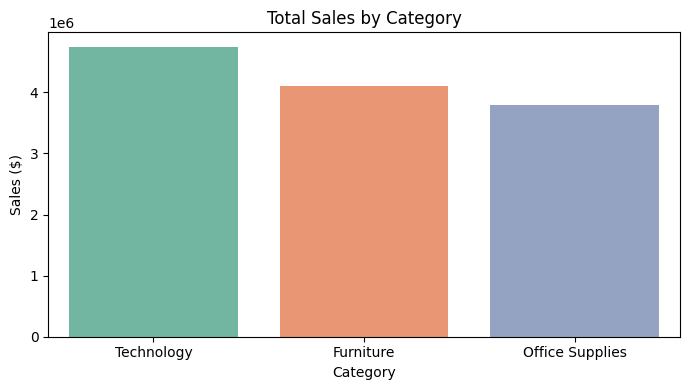

In [10]:
# Sales by Category
plt.figure(figsize=(7,4))
cat_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
sns.barplot(x=cat_sales.index, y=cat_sales.values, palette='Set2')
plt.title('Total Sales by Category')
plt.ylabel('Sales ($)')
plt.tight_layout()
plt.show()


In [11]:
# Top 5 customers
top5 = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(5)
print("Top 5 Customers by Sales:")
print(top5)


Top 5 Customers by Sales:
Customer Name
Tom Ashbrook          40488.07080
Tamara Chand          37457.33300
Greg Tran             35550.95428
Christopher Conant    35187.07640
Sean Miller           35170.93296
Name: Sales, dtype: float64


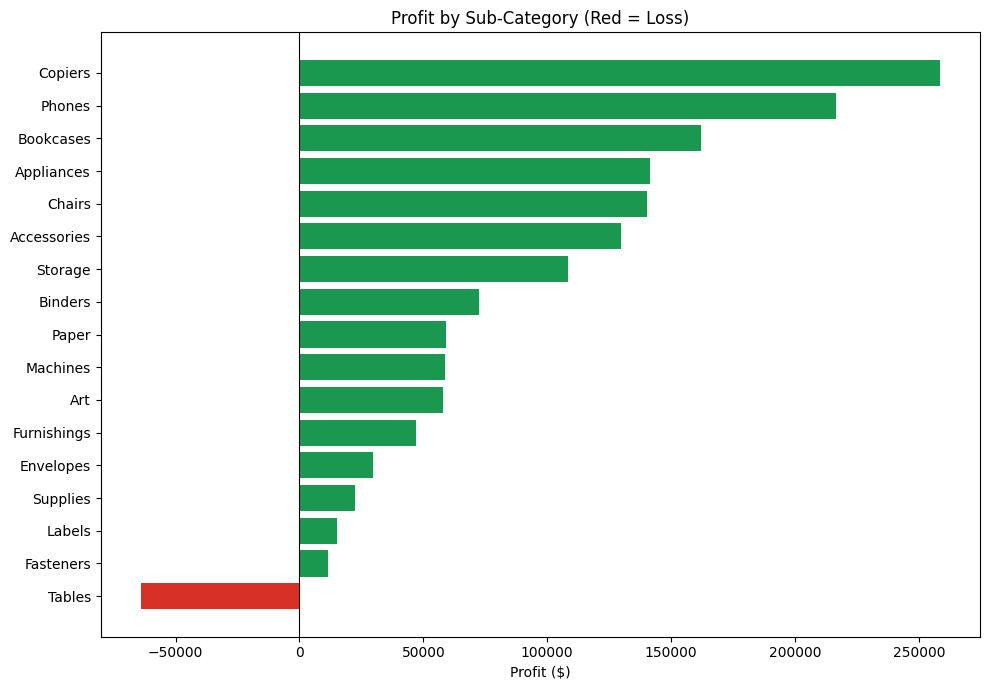

In [12]:
# Profit by Sub-Category
sub_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values()
colors = ['#d73027' if v < 0 else '#1a9850' for v in sub_profit.values]

plt.figure(figsize=(10,7))
plt.barh(sub_profit.index, sub_profit.values, color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Profit by Sub-Category (Red = Loss)')
plt.xlabel('Profit ($)')
plt.tight_layout()
plt.show()


## Conclusion

Key findings from the Global Superstore dashboard:

1. **Technology is the highest revenue category** — but Office Supplies has more consistent profit margins.
2. **Some Sub-Categories are loss-making** — Tables and Bookcases consistently show negative profit. These need pricing review.
3. **Top customers contribute significantly** — the top 5 customers alone generate a large portion of total revenue.
4. **Regional performance varies** — the dashboard allows filtering by region to identify underperforming areas.
5. **Business recommendation:** Stop discounting Tables and Bookcases. Focus marketing budget on the Technology category in high-performing regions.
